In [1]:
# ==============================================================================
# CÉLULA 1: SETUP E DEFINIÇÃO DO DIRETÓRIO RAIZ (ROOT)
# ==============================================================================
import os
import sys

# 1. Verificação do ambiente de execução (Nuvem vs Local)
if 'google.colab' in sys.modules:
    print("☁️ Ambiente detectado: Google Colab")
    from google.colab import drive
    drive.mount('/content/drive')

    # Insira abaixo o caminho exato onde clonou/salvou este repositório no seu Google Drive.
    caminho_projeto = '/content/drive/MyDrive/1) PESQUISA/ESALQ Data Science/tcc/tema_classificacao_queda_arvore/git/tcc_risco_queda_v-pub'

else:
    print("💻 Ambiente detectado: Local (Jupyter, VS Code, Spyder)")
    # Assume dinamicamente a pasta onde o notebook foi aberto como a raiz
    caminho_projeto = os.getcwd()

# 2. Configuração global do diretório de trabalho
try:
    os.chdir(caminho_projeto)
    if caminho_projeto not in sys.path:
        sys.path.append(caminho_projeto)
    print(f"✅ Diretório raiz configurado com sucesso: {os.getcwd()}")
except FileNotFoundError:
    print(f"❌ ERRO: A pasta '{caminho_projeto}' não foi encontrada.")
    print("Por favor, verifique se o caminho inserido está correto.")
    raise

☁️ Ambiente detectado: Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Diretório raiz configurado com sucesso: /content/drive/MyDrive/1) PESQUISA/ESALQ Data Science/tcc/tema_classificacao_queda_arvore/git/tcc_risco_queda_v-pub


In [2]:
# ==============================================================================
# CÉLULA 1: SETUP E CONFIGURAÇÕES INICIAIS
# ==============================================================================
import logging
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, precision_score, accuracy_score
from scipy.stats import ks_2samp
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display
from sklearn.model_selection import cross_val_predict


# Importando os seus módulos personalizados da pasta src
from src.optimization import otimizar_threshold_financeiro
from src.visualization import plotar_tradeoff_financeiro
from src.evaluation import calcular_metricas_limiar, extrair_matriz_quadrantes
from src.visualization import plotar_e_salvar_vif_completo

In [3]:
# CELULA 1C: 2. Configurações Globais de Visualização
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# Garante que a pasta de resultados existe
os.makedirs('results/figures', exist_ok=True)
os.makedirs('results/tables', exist_ok=True)

In [8]:
# Defina o nome do cenário atual aqui
nome_cenario = "abrangente"
if 'data_hora_base' not in globals():
    data_hora_base = datetime.now().strftime("_%Y%m%d-%H%M")
sufixo_data = f"{data_hora_base}_{nome_cenario}"

# Opcional: Melhora a qualidade da renderização no Colab
try:
    %config InlineBackend.figure_format = 'retina'
except:
    pass

In [5]:
# ==============================================================================
# CÉLULA 2: CARREGAMENTO DO MASTER DATASET E DEFINIÇÃO DO ESCOPO
# ==============================================================================

# 1. Carregamento do Novo Master Dataset (GPKG)
file_path = "data/processed/dataset_MASTER_sem-estradas.parquet"
print("📂 Carregando dataset master dedupilado...")
df_parquet = pd.read_parquet(file_path)

# Convertendo binário WKB para geometrias ativas
df_parquet['geometry'] = gpd.GeoSeries.from_wkb(df_parquet['geometry'])

# 2. Transformar agora com sucesso em GeoDataFrame
df_full = gpd.GeoDataFrame(df_parquet, geometry='geometry', crs="EPSG:31983")

print(f"🌍 Base Total Carregada: {len(df_full)} segmentos viários.")

📂 Carregando dataset master dedupilado...
🌍 Base Total Carregada: 110901 segmentos viários.


In [9]:
# 2. Base para Modelagem (Cópia para preservar o original)
df_modelagem = df_full.copy()

# 3. Definição do Alvo (Target) e Remoção de Vazamento (Leakage)
target = 'target_queda_bool'

if nome_cenario == 'focal':
    colunas_ignorar = [
    'cvc_nomelg', 'cvc_tplogr', 'cvc_classe',  # Nomes de ruas / IDs
    'target_historico_quedas',                 # Contagem exata de quedas (Vazamento)
    'geometry',                                # Geometria direta não vai para o modelo
    'socio_zona_fiscal_cat', 'socio_vulnerabilidade_idx',
    'socio_densidade_demog_hab_ha', 'infra_uso_solo_cat',
    'infra_escolas_contagem', 'infra_semaforos_contagem',
    'infra_iluminacao_contagem', 'infra_onibus_pontos_contagem',
    'geo_declividade_terreno_cat', 'geo_relevo_tipo_cat',
    'geo_litologia_tipo_cat', 'geo_solo_mole_area_m2',
]
else:
    colunas_ignorar = [
    'cvc_nomelg', 'cvc_tplogr', 'cvc_classe',  # Nomes de ruas / IDs
    'target_historico_quedas',                 # Contagem exata de quedas (Vazamento)
    'geometry',                                # Geometria direta não vai para o modelo

]

# Separação X e y
X = df_modelagem.drop(columns=colunas_ignorar + [target])
y = df_modelagem[target]

# 4. Identificação Automática de Dtypes
features_numericas = X.select_dtypes(include=['number']).columns.tolist()
features_categoricas = X.select_dtypes(include=['category', 'object']).columns.tolist()

print(f"📊 Modelagem iniciada com {len(df_modelagem)} amostras.")
print(f"🔹 Features Numéricas ({len(features_numericas)}): {features_numericas}")
print(f"🔹 Features Categóricas ({len(features_categoricas)}): {features_categoricas}")

# 5. Separação Treino/Teste (80/20) com Estratificação (ANTES DO PRE-PROCESSAMENTO)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"✅ Split concluído com sucesso. Treino: {len(X_train)} | Teste: {len(X_test)}")

📊 Modelagem iniciada com 110901 amostras.
🔹 Features Numéricas (17): ['via_extensao_km', 'via_azimute_graus', 'via_calcada_largura_min', 'via_calcada_declinacao_max', 'via_arvores_contagem', 'via_icc_confinamento_idx', 'stat_aiv_arvores_isoladas', 'stat_dva_vizinhanca_dist_med', 'stat_dva_vizinhanca_dist_std', 'stat_idag_densidade_grav_med', 'stat_idag_densidade_grav_std', 'socio_densidade_demog_hab_ha', 'infra_escolas_contagem', 'infra_semaforos_contagem', 'infra_iluminacao_contagem', 'infra_onibus_pontos_contagem', 'geo_solo_mole_area_m2']
🔹 Features Categóricas (6): ['socio_zona_fiscal_cat', 'socio_vulnerabilidade_idx', 'infra_uso_solo_cat', 'geo_declividade_terreno_cat', 'geo_relevo_tipo_cat', 'geo_litologia_tipo_cat']
✅ Split concluído com sucesso. Treino: 88720 | Teste: 22181


In [10]:
# ==============================================================================
# CÉLULA 3: CONSTRUÇÃO DO PRÉ-PROCESSADOR (PIPELINE)
# ==============================================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

print("⚙️ Construindo Pré-processador universal...")

# Pipeline Numérico: Imputação + Escalonamento
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline Categórico: Imputação + OneHot Encoding
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='DESCONHECIDO')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Processador que será encaixado nos modelos
pre_processador = ColumnTransformer([
    ('num', num_pipe, features_numericas),
    ('cat', cat_pipe, features_categoricas)
])

print("✅ Pré-processador pronto para ser acoplado aos modelos.")

⚙️ Construindo Pré-processador universal...
✅ Pré-processador pronto para ser acoplado aos modelos.


🔬 Iniciando Análise de Multicolinearidade (VIF) nos dados de Treino...

📊 Resultado do VIF (Atenção para valores > 5):


,Variável,VIF
4,via_calcada_declinacao_max,1.163582
6,via_icc_confinamento_idx,1.285291
9,stat_dva_vizinhanca_dist_std,1.292809
8,stat_dva_vizinhanca_dist_med,1.321777
7,stat_aiv_arvores_isoladas,1.342118
3,via_calcada_largura_min,1.364358
1,via_extensao_km,1.596420
5,via_arvores_contagem,1.715402
10,stat_idag_densidade_grav_med,2.485299
11,stat_idag_densidade_grav_std,2.522774


✅ Tabela VIF exportada: results/tables/02_tabela_vif__20260402-1338_abrangente.csv

🎨 Gerando gráfico dinâmico de Multicolinearidade...


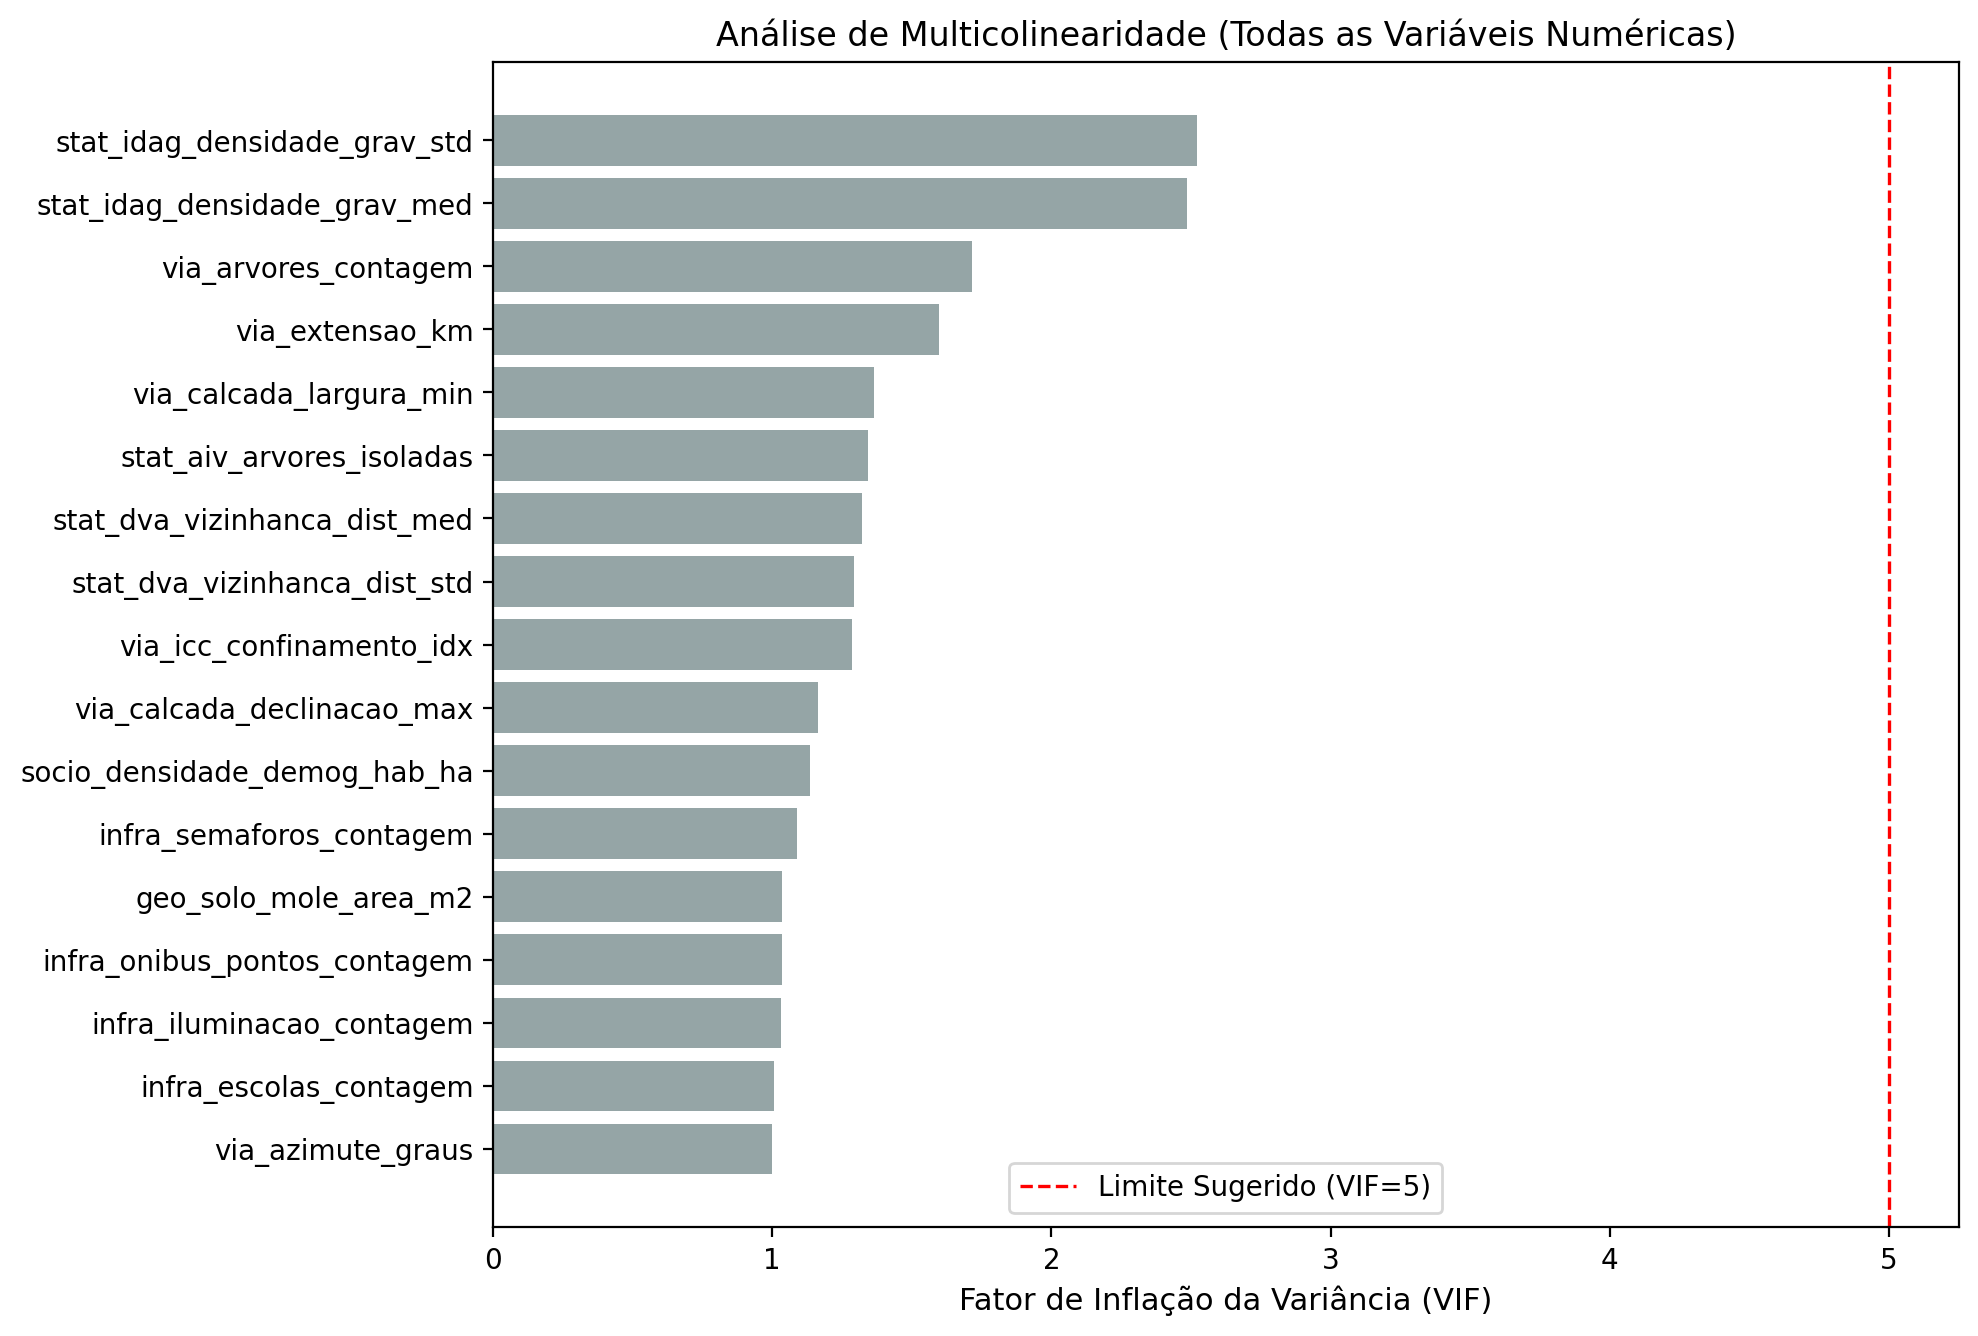

In [11]:
# ==============================================================================
# CÉLULA 4: AUDITORIA ESTATÍSTICA E COLINEARIDADE (VIF)
# ==============================================================================
import os
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Lembre-se de importar a função no topo do seu notebook:
# from src.visualization import plotar_e_salvar_vif_completo

print("🔬 Iniciando Análise de Multicolinearidade (VIF) nos dados de Treino...")

# 1. Aplicamos o pipeline numérico (Imputação + Scaler) APENAS no X_train para evitar vazamento
X_train_num_clean = num_pipe.fit_transform(X_train[features_numericas])
X_train_num_df = pd.DataFrame(X_train_num_clean, columns=features_numericas, index=X_train.index)

# 2. Adicionamos a constante exigida pelo statsmodels
X_vif_const = add_constant(X_train_num_df)

# 3. Cálculo do VIF
vif_data = pd.DataFrame({
    "Variável": X_vif_const.columns,
    "VIF": [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]
})

vif_data = vif_data[vif_data['Variável'] != 'const'].sort_values('VIF', ascending=True)

# 4. Exibição e Exportação da Tabela (CSV)
print("\n📊 Resultado do VIF (Atenção para valores > 5):")
display(vif_data.tail(10))

os.makedirs('results/tables', exist_ok=True)
nome_arquivo_csv = f'results/tables/02_tabela_vif_{sufixo_data}.csv'
vif_data.round(4).to_csv(nome_arquivo_csv, sep=';', decimal=',', index=False)
print(f"✅ Tabela VIF exportada: {nome_arquivo_csv}")

# ================= NOVA PARTE: GRÁFICO E NARRATIVA =================

# 5. Gerar Gráfico Dinâmico chamando o src/
print("\n🎨 Gerando gráfico dinâmico de Multicolinearidade...")
sufixo_grafico = f"_{sufixo_data}" if 'sufixo_data' in globals() else ''
plotar_e_salvar_vif_completo(vif_data, sufixo=sufixo_grafico)


In [13]:
# ==============================================================================
# CÉLULA 5A: INFERÊNCIA ESTATÍSTICA (REGRESSÃO LOGÍSTICA E TESTE DE HIPÓTESES)
# ==============================================================================
import statsmodels.api as sm
import numpy as np
import pandas as pd
import os

print("🔬 Iniciando Teste de Hipóteses com Variáveis de Controle...")

# 1. Definir as variáveis separando por tipo
cols_numericas = [
    'stat_idag_densidade_grav_med',
    'stat_aiv_arvores_isoladas',
    'via_icc_confinamento_idx',
    'stat_dva_vizinhanca_dist_med',
]

cols_categoricas = [
    'socio_zona_fiscal_cat' # Variável de controle do viés de notificação
]

# Extrair da base completa (X e y)
X_inf = X[cols_numericas + cols_categoricas].copy()
y_inf = y.copy()

# 2. Tratamento de Valores Nulos (NaN)
# Numéricas recebem a mediana
for col in cols_numericas:
    X_inf[col] = X_inf[col].fillna(X_inf[col].median())

# Categóricas recebem uma categoria neutra/ausente
for col in cols_categoricas:
    X_inf[col] = X_inf[col].fillna('NAO_INFORMADO')

# 3. Transformação em Variáveis Dummy (One-Hot Encoding)
# drop_first=True é OBRIGATÓRIO na estatística para definir uma categoria como "referência"
X_inf = pd.get_dummies(X_inf, columns=cols_categoricas, drop_first=True, dtype=float)

# 4. ALINHAMENTO DE ÍNDICES (Evita o erro "indices are not aligned")
X_inf = X_inf.reset_index(drop=True)
y_inf = y_inf.reset_index(drop=True)

# 5. Adicionar a constante (intercepto) e Ajustar o modelo Logit
X_inf = sm.add_constant(X_inf)
modelo_inf = sm.Logit(y_inf, X_inf).fit(disp=False)

# 6. Exibir o sumário na tela
print("\n" + "="*80)
print("📊 RESULTADO DA REGRESSÃO LOGÍSTICA AJUSTADA")
print("="*80)
print(modelo_inf.summary())

# 7. CONSTRUÇÃO DO RELATÓRIO COMPLETO (DATAFRAME)
conf_int = modelo_inf.conf_int()

df_estatistica = pd.DataFrame({
    'Coeficiente (Beta)': modelo_inf.params,
    'Estatística Z': modelo_inf.tvalues,
    'P-Valor': modelo_inf.pvalues,
    'Odds Ratio (OR)': np.exp(modelo_inf.params),
    'IC 95% Inferior (OR)': np.exp(conf_int[0]),
    'IC 95% Superior (OR)': np.exp(conf_int[1])
})

df_estatistica_formatado = df_estatistica.round(4)
df_estatistica_formatado['Significativo (5%)'] = df_estatistica_formatado['P-Valor'].apply(lambda x: 'Sim' if x < 0.05 else 'Não')

print("\n" + "="*80)
print("📈 TABELA DE MÉTRICAS COMPILADAS (Pronta para Exportação)")
print("="*80)
display(df_estatistica_formatado)

# 8. EXPORTAÇÃO PARA CSV
sufixo_data = sufixo_data if 'sufixo_data' in globals() else ''
os.makedirs('results/tables', exist_ok=True)
caminho_csv = f'results/tables/02_inferencia_estatistica_or{sufixo_data}.csv'

df_estatistica_formatado.to_csv(caminho_csv, sep=';', decimal=',', index=True, encoding='utf-8-sig')

print(f"\n✅ Relatório estatístico completo exportado com sucesso para: {caminho_csv}")

🔬 Iniciando Teste de Hipóteses com Variáveis de Controle...

📊 RESULTADO DA REGRESSÃO LOGÍSTICA AJUSTADA
                           Logit Regression Results                           
Dep. Variable:      target_queda_bool   No. Observations:               110901
Model:                          Logit   Df Residuals:                   110892
Method:                           MLE   Df Model:                            8
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                 0.03686
Time:                        13:39:35   Log-Likelihood:                -25957.
converged:                       True   LL-Null:                       -26950.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.5456      0.088    -29.017      0.

,Coeficiente (Beta),Estatística Z,P-Valor,Odds Ratio (OR),IC 95% Inferior (OR),IC 95% Superior (OR),Significativo (5%)
const,-2.5456,-29.0173,0.0000,0.0784,0.0660,0.0931,Sim
stat_idag_densidade_grav_med,-0.2801,-2.0502,0.0403,0.7557,0.5781,0.9877,Sim
stat_aiv_arvores_isoladas,0.2792,26.2376,0.0000,1.3221,1.2948,1.3500,Sim
via_icc_confinamento_idx,0.0536,4.4782,0.0000,1.0551,1.0306,1.0801,Sim
stat_dva_vizinhanca_dist_med,-0.0130,-13.1192,0.0000,0.9871,0.9852,0.9890,Sim
socio_zona_fiscal_cat_ZF-1,0.5500,6.3364,0.0000,1.7333,1.4621,2.0548,Sim
socio_zona_fiscal_cat_ZF-2,-0.0583,-0.6784,0.4975,0.9434,0.7972,1.1164,Não
socio_zona_fiscal_cat_ZF-3,-0.4884,-5.5759,0.0000,0.6136,0.5168,0.7285,Sim
socio_zona_fiscal_cat_ZF-4,-0.5833,-5.2758,0.0000,0.5581,0.4493,0.6931,Sim



✅ Relatório estatístico completo exportado com sucesso para: results/tables/02_inferencia_estatistica_or_20260402-1338_abrangente.csv


In [23]:
# ==============================================================================
# CÉLULA 5B: TREINAMENTO DOS BASELINES E REGRESSÕES LINEARES
# ==============================================================================
print("🚀 Iniciando o Treinamento dos Baselines e Modelos Lineares...")

# 1. BASELINE 1: ALEATÓRIO (Chute Uniforme 50/50)
pipe_dummy_random = DummyClassifier(strategy='uniform', random_state=42)
pipe_dummy_random.fit(X_train, y_train)
print("✅ Baseline 1 (Aleatório) treinado.")

# 2. BASELINE 2: MAIORIA (Prevê sempre a classe dominante)
pipe_dummy_majority = DummyClassifier(strategy='most_frequent')
pipe_dummy_majority.fit(X_train, y_train)
print("✅ Baseline 2 (Maioria) treinado.")

# 3. BASELINE 3: REGRESSÃO LOGÍSTICA SIMPLES (Sem Penalidade)
pipe_logistica = Pipeline([
    ('pre', pre_processador),
    ('modelo', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])
pipe_logistica.fit(X_train, y_train)
print("✅ Baseline 3 (Logística Padrão) treinado.")

# 4. MODELO LINEAR PRINCIPAL: LASSO (Com Penalidade L1)
pipe_lasso = Pipeline([
    ('pre', pre_processador),
    ('modelo', LogisticRegression(
        penalty='l1', solver='liblinear', class_weight='balanced',
        random_state=42, max_iter=2000, C=1.0
    ))
])
pipe_lasso.fit(X_train, y_train)
print("✅ Modelo Principal Linear (LASSO) treinado!")

# ==============================================================================
# EXTRAÇÃO DE COEFICIENTES DO LASSO (FATORES DE RISCO E PROTEÇÃO)
# ==============================================================================
nomes_features_finais = pipe_lasso.named_steps['pre'].get_feature_names_out()
nomes_limpos = [nome.replace('num__', '').replace('cat__', '') for nome in nomes_features_finais]

pesos_lasso = pipe_lasso.named_steps['modelo'].coef_[0]

df_coeficientes = pd.DataFrame({'Variavel': nomes_limpos, 'Peso_Lasso': pesos_lasso})
df_coeficientes = df_coeficientes.sort_values(by='Peso_Lasso', ascending=False)

sobreviveram = df_coeficientes[df_coeficientes['Peso_Lasso'] != 0].shape[0]
zeradas = df_coeficientes[df_coeficientes['Peso_Lasso'] == 0].shape[0]

print(f"\n🔍 RESUMO DA REGRESSÃO LASSO: {sobreviveram} variáveis mantidas, {zeradas} zeradas.")

# Exportação estrita para CSV
df_coeficientes.to_csv(f'results/tables/04_pesos_lasso_{sufixo_data}.csv', sep=';', decimal=',', index=False)

🚀 Iniciando o Treinamento dos Baselines e Modelos Lineares...
✅ Baseline 1 (Aleatório) treinado.
✅ Baseline 2 (Maioria) treinado.
✅ Baseline 3 (Logística Padrão) treinado.
✅ Modelo Principal Linear (LASSO) treinado!

🔍 RESUMO DA REGRESSÃO LASSO: 66 variáveis mantidas, 2 zeradas.


In [24]:
# ==============================================================================
# CÉLULA 6: OTIMIZAÇÃO DO XGBOOST (K-FOLD ESPACIAL)
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

print("⚙️ Iniciando configuração do XGBoost...")

# 1. Agrupamento Espacial e Pesos
groups_train = df_modelagem.loc[X_train.index, 'socio_zona_fiscal_cat']
peso_positivo = (len(y_train) - y_train.sum()) / y_train.sum() if y_train.sum() > 0 else 1

pipe_xgb_base = Pipeline([
    ('pre', pre_processador),
    ('modelo', XGBClassifier(random_state=42, scale_pos_weight=peso_positivo))
])

# 2. Lógica de Busca e Cache (Estritamente CSV)
caminho_params_csv = f'results/tables/05_xgb_best_params_{nome_cenario}.csv'

if os.path.exists(caminho_params_csv):
    print(f"📥 Cache encontrado! Carregando parâmetros de: {caminho_params_csv}")
    df_params = pd.read_csv(caminho_params_csv, sep=';')
    best_params = df_params.iloc[0].to_dict()

    # Garantindo que parâmetros de contagem de árvores/profundidade voltem como Inteiros
    for col in ['modelo__n_estimators', 'modelo__max_depth']:
        if col in best_params:
            best_params[col] = int(best_params[col])

else:
    print("⏳ Iniciando Validação Cruzada Espacial (RandomizedSearchCV)...")
    param_dist = {
        'modelo__n_estimators': [100, 200, 300],
        'modelo__max_depth': [3, 4, 5, 7],
        'modelo__learning_rate': [0.01, 0.05, 0.1],
        'modelo__subsample': [0.7, 0.8, 0.9],
        'modelo__reg_alpha': [0, 0.1, 1, 10],
        'modelo__reg_lambda': [1, 5, 10, 20]
    }

    search_xgb = RandomizedSearchCV(
        pipe_xgb_base, param_distributions=param_dist, n_iter=10,
        scoring='recall', cv=GroupKFold(n_splits=5), verbose=1,
        random_state=42, n_jobs=-1
    )

    search_xgb.fit(X_train, y_train, groups=groups_train)
    best_params = search_xgb.best_params_

    # Exportação estrita para CSV
    pd.DataFrame([best_params]).to_csv(caminho_params_csv, sep=';', index=False)
    print(f"💾 Parâmetros otimizados salvos em CSV: {caminho_params_csv}")

# 3. Treinamento Final do XGBoost
print("\n🌳 Treinando XGBoost Final com os melhores parâmetros...")
pipe_xgb_final = pipe_xgb_base.set_params(**best_params)
pipe_xgb_final.fit(X_train, y_train)

print("✅ XGBoost treinado e pronto para predições!")

⚙️ Iniciando configuração do XGBoost...
📥 Cache encontrado! Carregando parâmetros de: results/tables/05_xgb_best_params_abrangente.csv

🌳 Treinando XGBoost Final com os melhores parâmetros...
✅ XGBoost treinado e pronto para predições!


🎲 Gerando probabilidades para a base de Teste (20%)...


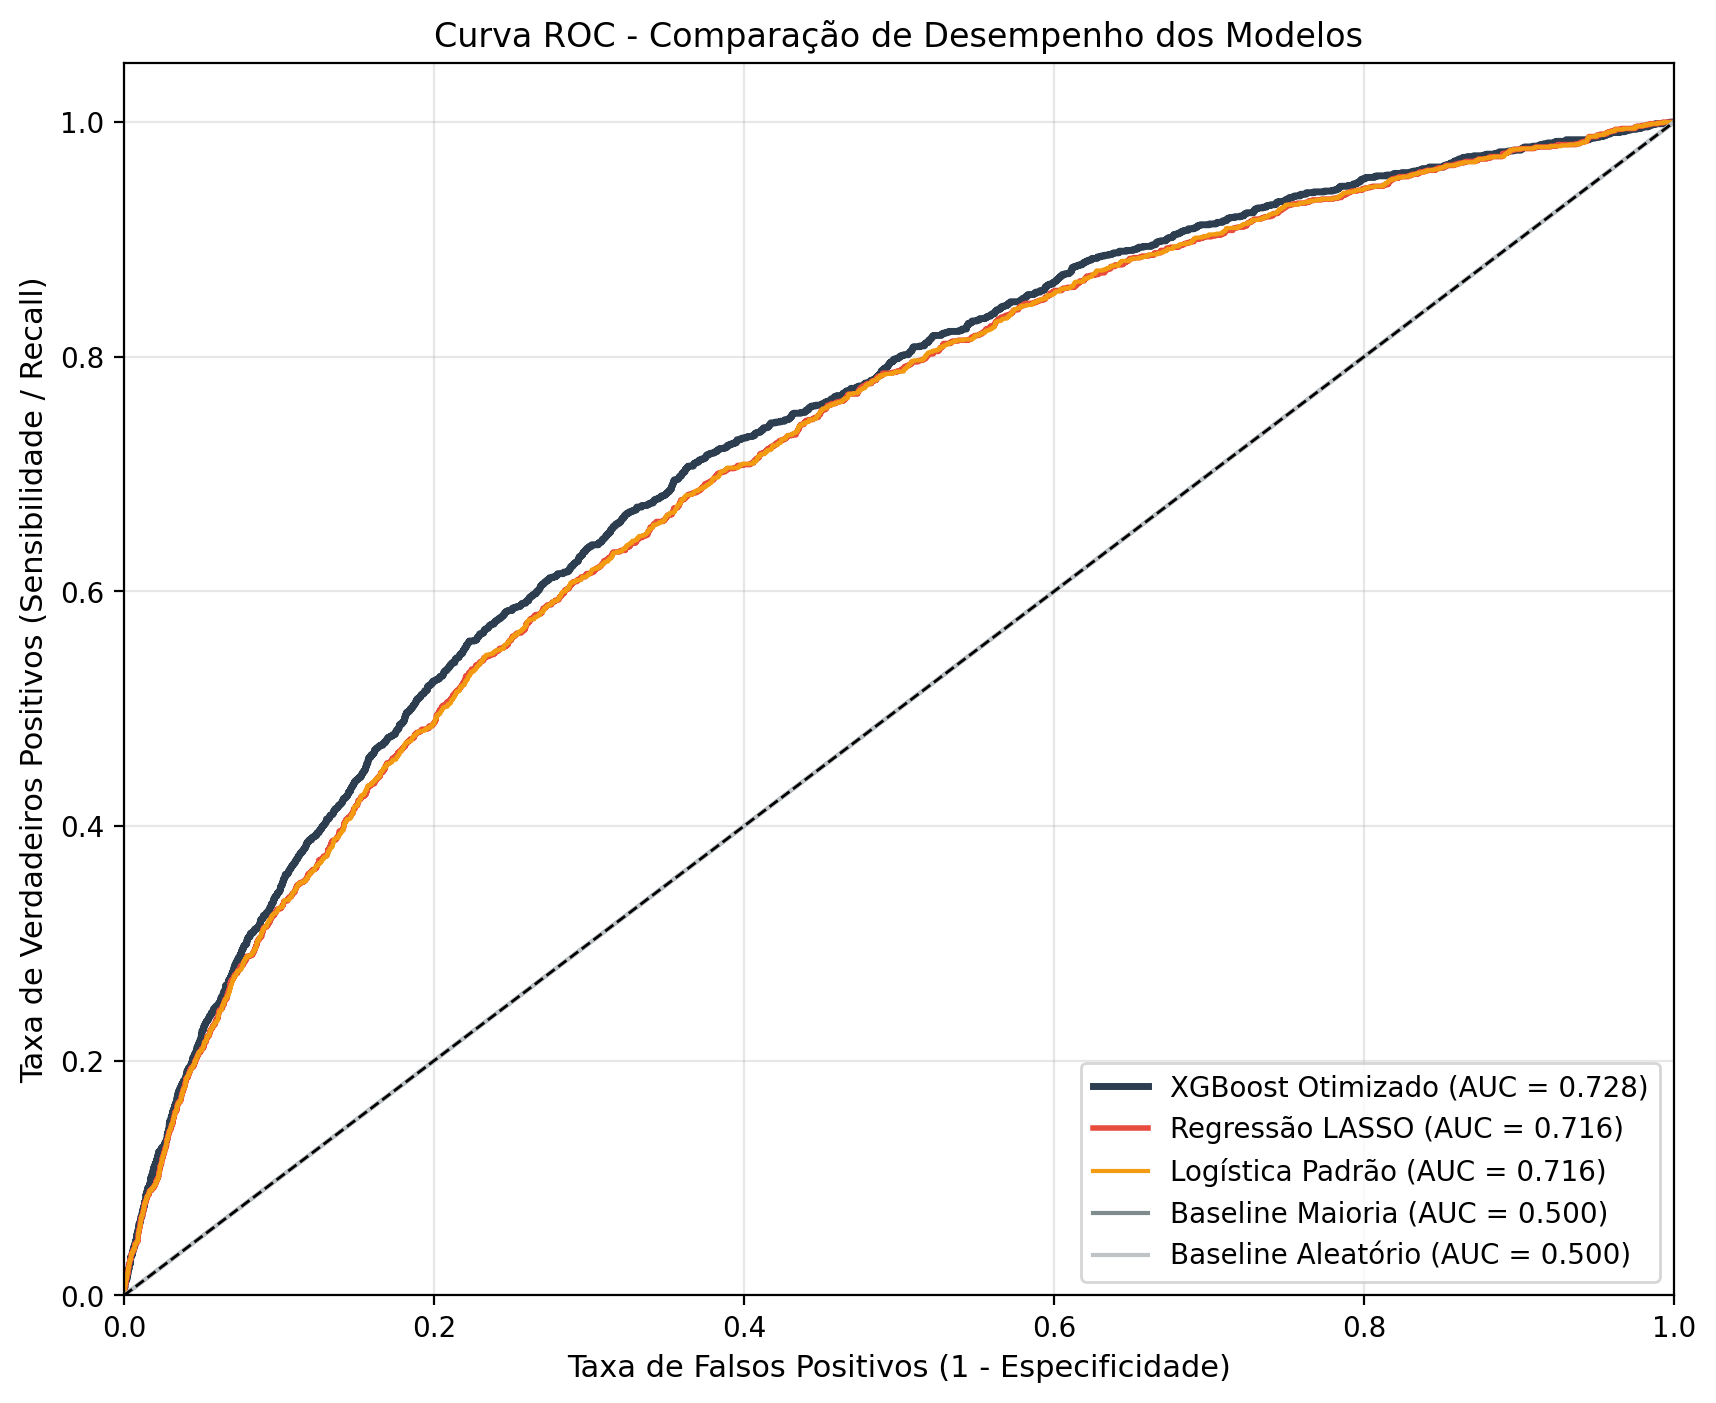

✅ Curva ROC exportada em PNG e Predições salvas em CSV.


In [25]:
# ==============================================================================
# CÉLULA 7: PREDIÇÕES NA BASE DE TESTE E CURVA ROC
# ==============================================================================
from sklearn.metrics import roc_curve, auc, roc_auc_score

print("🎲 Gerando probabilidades para a base de Teste (20%)...")

# 1. Geração das Probabilidades
df_test_results = pd.DataFrame({'target_real': y_test})

# Extraindo apenas a probabilidade da classe 1 (Queda)
df_test_results['prob_aleatorio'] = pipe_dummy_random.predict_proba(X_test)[:, 1]
df_test_results['prob_maioria'] = pipe_dummy_majority.predict_proba(X_test)[:, 1]
df_test_results['prob_logistica'] = pipe_logistica.predict_proba(X_test)[:, 1]
df_test_results['prob_lasso'] = pipe_lasso.predict_proba(X_test)[:, 1]
df_test_results['prob_xgb'] = pipe_xgb_final.predict_proba(X_test)[:, 1]

# Exporta matriz de resultados brutos
df_test_results.to_csv(f'results/tables/06_predicoes_teste_{sufixo_data}.csv', index=False, sep=';', decimal=',')

# 2. Plotagem da Curva ROC (Comparação de Modelos)
plt.figure(figsize=(10, 8))

dicionario_modelos = {
    'XGBoost Otimizado': ('prob_xgb', '#2c3e50', 2.5),
    'Regressão LASSO': ('prob_lasso', '#e74c3c', 2.0),
    'Logística Padrão': ('prob_logistica', '#f39c12', 1.5),
    'Baseline Maioria': ('prob_maioria', '#7f8c8d', 1.5),
    'Baseline Aleatório': ('prob_aleatorio', '#bdc3c7', 1.5)
}

for nome, (coluna, cor, lw) in dicionario_modelos.items():
    fpr, tpr, _ = roc_curve(y_test, df_test_results[coluna])
    auc_score = roc_auc_score(y_test, df_test_results[coluna])
    plt.plot(fpr, tpr, color=cor, lw=lw, label=f'{nome} (AUC = {auc_score:.3f})')

# Linha de chance (50%)
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade / Recall)')
plt.title('Curva ROC - Comparação de Desempenho dos Modelos')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Exportação do Gráfico
caminho_roc = f'results/figures/01_curva_roc_modelos_{sufixo_data}.png'
plt.savefig(caminho_roc, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Curva ROC exportada em PNG e Predições salvas em CSV.")

In [26]:
# ==============================================================================
# CÉLULA 8: SIMULAÇÃO DE CUSTO OPERACIONAL (TRADE-OFF TABULAR)
# ==============================================================================
import pandas as pd
from sklearn.metrics import confusion_matrix, recall_score, precision_score
import os

print("🚦 Simulando cenários operacionais de ponto de corte (Threshold)...")

limiares_teste = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15]
resultados_simulacao = []

for limiar in limiares_teste:
    # Usando as probabilidades do XGBoost geradas na Célula 7
    y_pred_sim = (df_test_results['prob_xgb'] >= limiar).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_sim).ravel()

    recall = recall_score(y_test, y_pred_sim)
    precisao = precision_score(y_test, y_pred_sim, zero_division=0)

    resultados_simulacao.append({
        'Threshold': limiar,
        'Recall (Segurança) %': f"{recall*100:.1f}%",
        'Precisão (Assertividade) %': f"{precisao*100:.1f}%",
        'Quedas Detectadas (VP)': tp,
        'Riscos Omitidos (FN)': fn,
        'Alarmes Falsos (FP)': fp,
        'Vistorias Totais (Carga)': tp + fp
    })

df_simulacao = pd.DataFrame(resultados_simulacao).set_index('Threshold')
display(df_simulacao)

caminho_simulacao = f'results/tables/07_simulacao_custo_operacional_{sufixo_data}.csv'
df_simulacao.to_csv(caminho_simulacao, sep=';', decimal=',')
print(f"\n✅ Tabela de simulação exportada para: {caminho_simulacao}")

🚦 Simulando cenários operacionais de ponto de corte (Threshold)...


,Recall (Segurança) %,Precisão (Assertividade) %,Quedas Detectadas (VP),Riscos Omitidos (FN),Alarmes Falsos (FP),Vistorias Totais (Carga)
Threshold,,,,,,
0.50,66.0%,12.7%,966,497,6643,7609
0.45,74.4%,11.1%,1089,374,8713,9802
0.40,82.0%,9.9%,1200,263,10973,12173
0.35,88.9%,8.9%,1300,163,13296,14596
0.30,93.6%,8.1%,1370,93,15625,16995
0.25,96.7%,7.4%,1414,49,17788,19202
0.20,98.5%,6.9%,1441,22,19374,20815
0.15,99.9%,6.6%,1461,2,20619,22080



✅ Tabela de simulação exportada para: results/tables/07_simulacao_custo_operacional__20260402-1338_abrangente.csv


🔍 Otimizando o ponto de corte com base nos custos da PMSP...
🎯 Threshold Operacional Ideal: 0.44


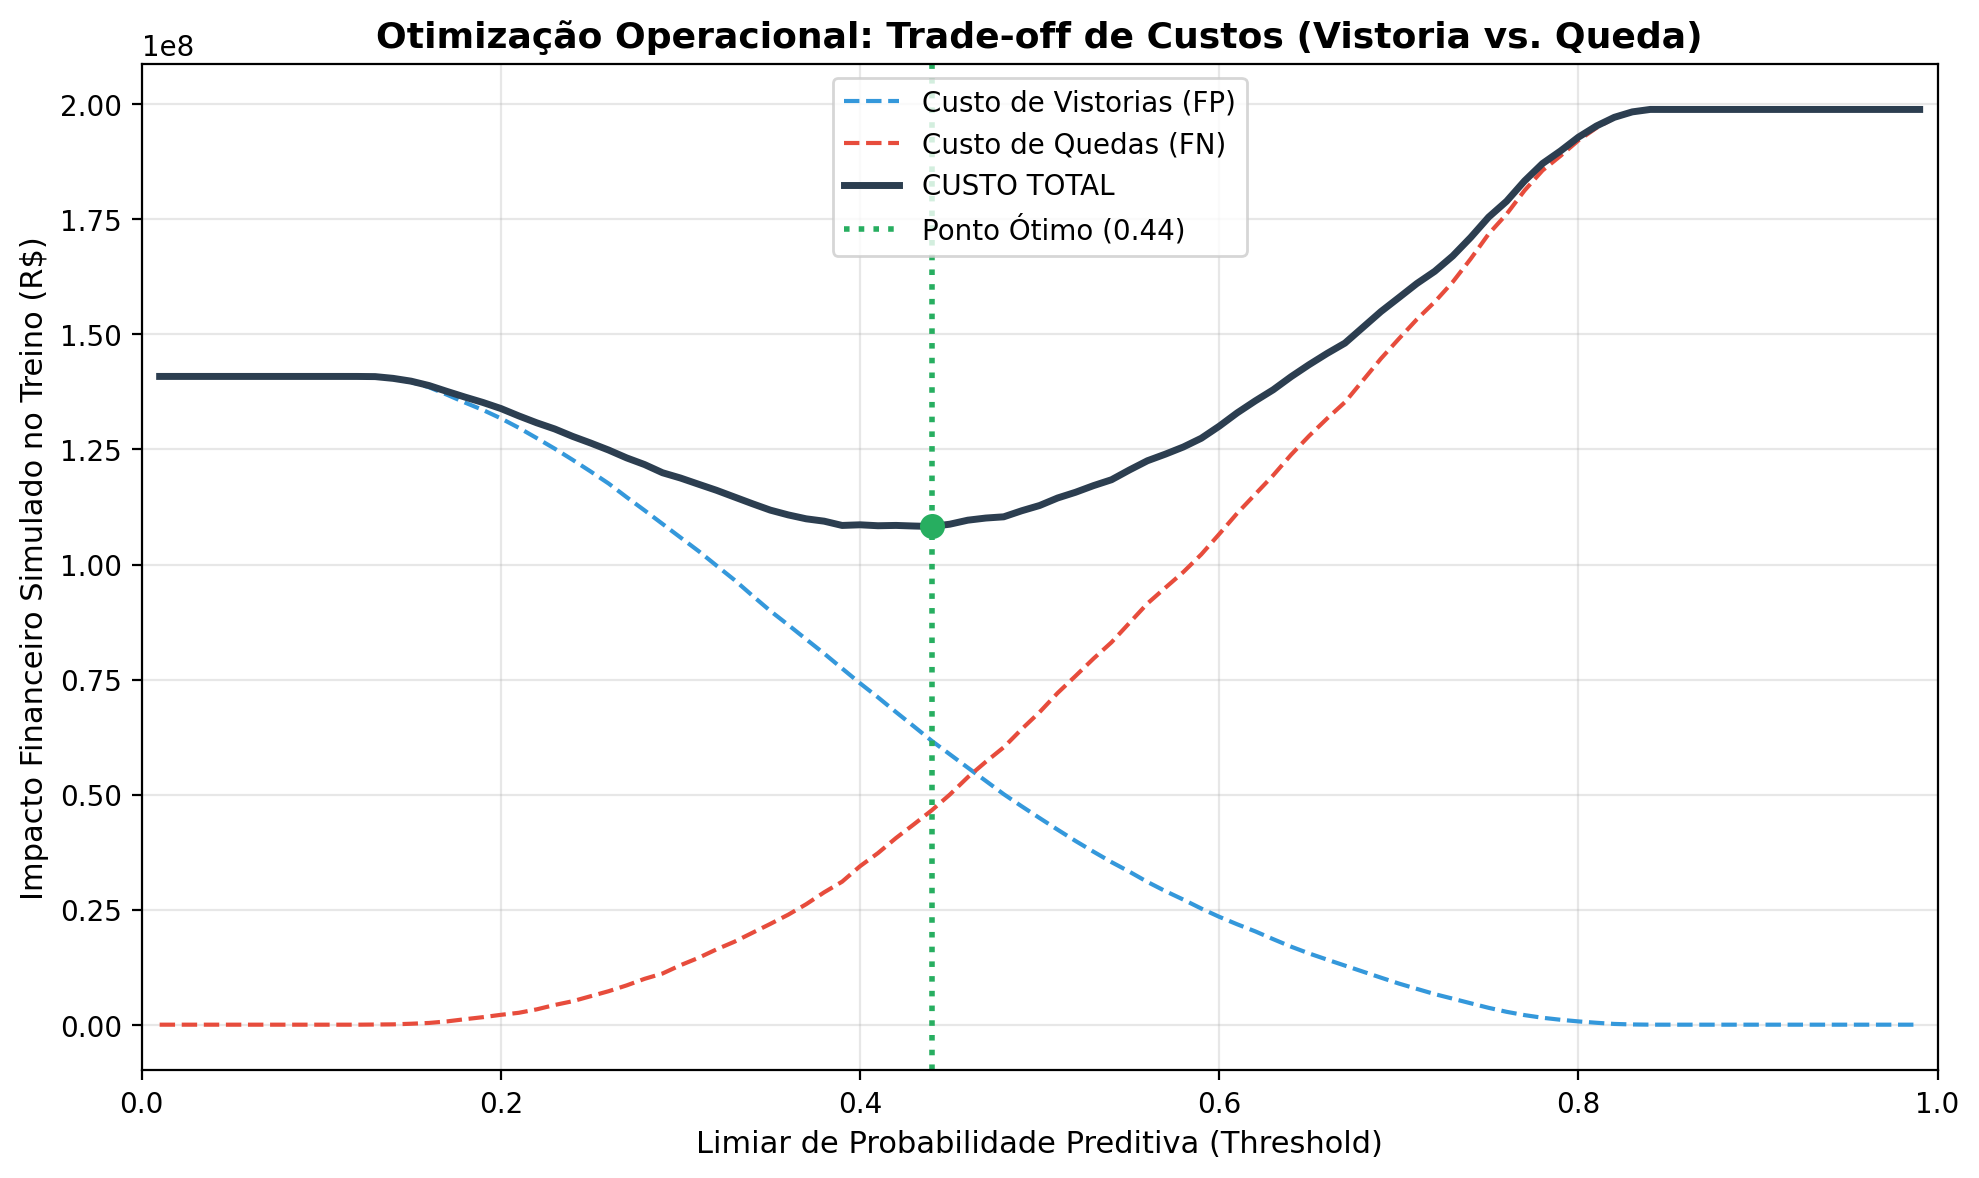

In [27]:
# ==============================================================================
# CÉLULA 8: OTIMIZAÇÃO DO THRESHOLD (TRADE-OFF FINANCEIRO E OPERACIONAL)
# ==============================================================================
print("🔍 Otimizando o ponto de corte com base nos custos da PMSP...")

# 1. Geração Out-Of-Fold no Treino (Rigor Científico contra Leakage)
y_prob_train_oof = cross_val_predict(
    pipe_xgb_final, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1
)[:, 1]

# 2. Chama a função de negócio do src/optimization.py
# (Premissa: Vistoria = R$ 1.700 | Queda = X vezes o valor da vistoria)
resultado_otimizacao = otimizar_threshold_financeiro(
    y_train,
    y_prob_train_oof,
    custo_fp=1700,
    multiplicador_fn=20 # ATUALIZE AQUI
)

threshold_otimo = resultado_otimizacao['threshold_otimo']
menor_custo = resultado_otimizacao['menor_custo_total']
print(f"🎯 Threshold Operacional Ideal: {threshold_otimo:.2f}")

# 3. Plota e exporta o gráfico chamando o src/visualization.py
caminho_figura_tradeoff = f'results/figures/02_simulacao_custo_threshold_{sufixo_data}.png'

plotar_tradeoff_financeiro(
    historico_custos=resultado_otimizacao['historico'],
    threshold_otimo=threshold_otimo,
    menor_custo=menor_custo,
    caminho_exportacao=caminho_figura_tradeoff
)

In [28]:
# ==============================================================================
# CÉLULA 9: AVALIAÇÃO GLOBAL DE DESEMPENHO (MÉTRICAS E MATRIZES)
# ==============================================================================
print("📊 Consolidando Métricas Avançadas e Matrizes de Confusão...")

# 1. Aplicando a função do src/evaluation.py para as Métricas Globais
tabela_metricas = {
    'Baseline (Maioria)': calcular_metricas_limiar(y_test, df_test_results['prob_maioria'], 0.50),
    'Baseline (Aleatório)': calcular_metricas_limiar(y_test, df_test_results['prob_aleatorio'], 0.50),
    f'Logística (Thr {threshold_otimo:.2f})': calcular_metricas_limiar(y_test, df_test_results['prob_logistica'], threshold_otimo),
    f'LASSO (Thr {threshold_otimo:.2f})': calcular_metricas_limiar(y_test, df_test_results['prob_lasso'], threshold_otimo),
    f'XGBoost (Thr {threshold_otimo:.2f})': calcular_metricas_limiar(y_test, df_test_results['prob_xgb'], threshold_otimo)
}

col_metricas = ['Recall (Segurança)', 'AUC', 'Gini', 'KS', 'Especificidade', 'Precisão', 'Acurácia']
df_metricas = pd.DataFrame.from_dict(tabela_metricas, orient='index', columns=col_metricas)

# 2. Aplicando a função do src/evaluation.py para as Matrizes de Confusão
tabela_matrizes = {
    'Baseline (Maioria)': extrair_matriz_quadrantes(y_test, df_test_results['prob_maioria'], 0.50),
    'Baseline (Aleatório)': extrair_matriz_quadrantes(y_test, df_test_results['prob_aleatorio'], 0.50),
    f'Logística (Thr {threshold_otimo:.2f})': extrair_matriz_quadrantes(y_test, df_test_results['prob_logistica'], threshold_otimo),
    f'LASSO (Thr {threshold_otimo:.2f})': extrair_matriz_quadrantes(y_test, df_test_results['prob_lasso'], threshold_otimo),
    f'XGBoost (Thr {threshold_otimo:.2f})': extrair_matriz_quadrantes(y_test, df_test_results['prob_xgb'], threshold_otimo)
}

df_matrizes = pd.DataFrame.from_dict(tabela_matrizes, orient='index')

# 3. Exibição
print("\n📋 1. MÉTRICAS GLOBAIS DE DESEMPENHO (KS, GINI, AUC):")
display(df_metricas)

print("\n📋 2. IMPACTO OPERACIONAL (MATRIZES DE CONFUSÃO):")
display(df_matrizes)

# 4. Exportação Rigorosa (CSV PT-BR)
caminho_metricas = f'results/tables/08_tabela_metricas_finais_{sufixo_data}.csv'
caminho_matrizes = f'results/tables/09_comparacao_matrizes_{sufixo_data}.csv'

df_metricas.to_csv(caminho_metricas, sep=';', decimal=',')
df_matrizes.to_csv(caminho_matrizes, sep=';', decimal=',')
print("✅ Tabelas de avaliação final exportadas com sucesso!")

📊 Consolidando Métricas Avançadas e Matrizes de Confusão...

📋 1. MÉTRICAS GLOBAIS DE DESEMPENHO (KS, GINI, AUC):


,Recall (Segurança),AUC,Gini,KS,Especificidade,Precisão,Acurácia
Baseline (Maioria),0.0000,0.5000,0.0000,0.0000,1.0000,0.0000,0.9340
Baseline (Aleatório),1.0000,0.5000,0.0000,0.0000,0.0000,0.0660,0.0660
Logística (Thr 0.44),0.7184,0.7158,0.4315,0.3195,0.5863,0.1092,0.5950
LASSO (Thr 0.44),0.7198,0.7158,0.4317,0.3187,0.5855,0.1092,0.5943
XGBoost (Thr 0.44),0.7567,0.7282,0.4563,0.3427,0.5577,0.1078,0.5708



📋 2. IMPACTO OPERACIONAL (MATRIZES DE CONFUSÃO):


,Verdadeiros Negativos (TN - Seguras),Falsos Positivos (FP - Alarme Falso),Falsos Negativos (FN - Queda Omitida),Verdadeiros Positivos (TP - Queda Detectada),Total de Vistorias Geradas (TP + FP)
Baseline (Maioria),20718,0,1463,0,0
Baseline (Aleatório),0,20718,0,1463,22181
Logística (Thr 0.44),12146,8572,412,1051,9623
LASSO (Thr 0.44),12130,8588,410,1053,9641
XGBoost (Thr 0.44),11554,9164,356,1107,10271


✅ Tabelas de avaliação final exportadas com sucesso!


📊 Extraindo a importância de todas as variáveis dos modelos...


/tmp/ipykernel_43829/2599018128.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='XGBoost (Força %)', y='Feature', data=df_xgb_plot, ax=axes[0], palette='viridis')
/tmp/ipykernel_43829/2599018128.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Lasso (Coeficiente)', y='Feature', data=df_lasso_plot, ax=axes[1], palette=cores_lasso)


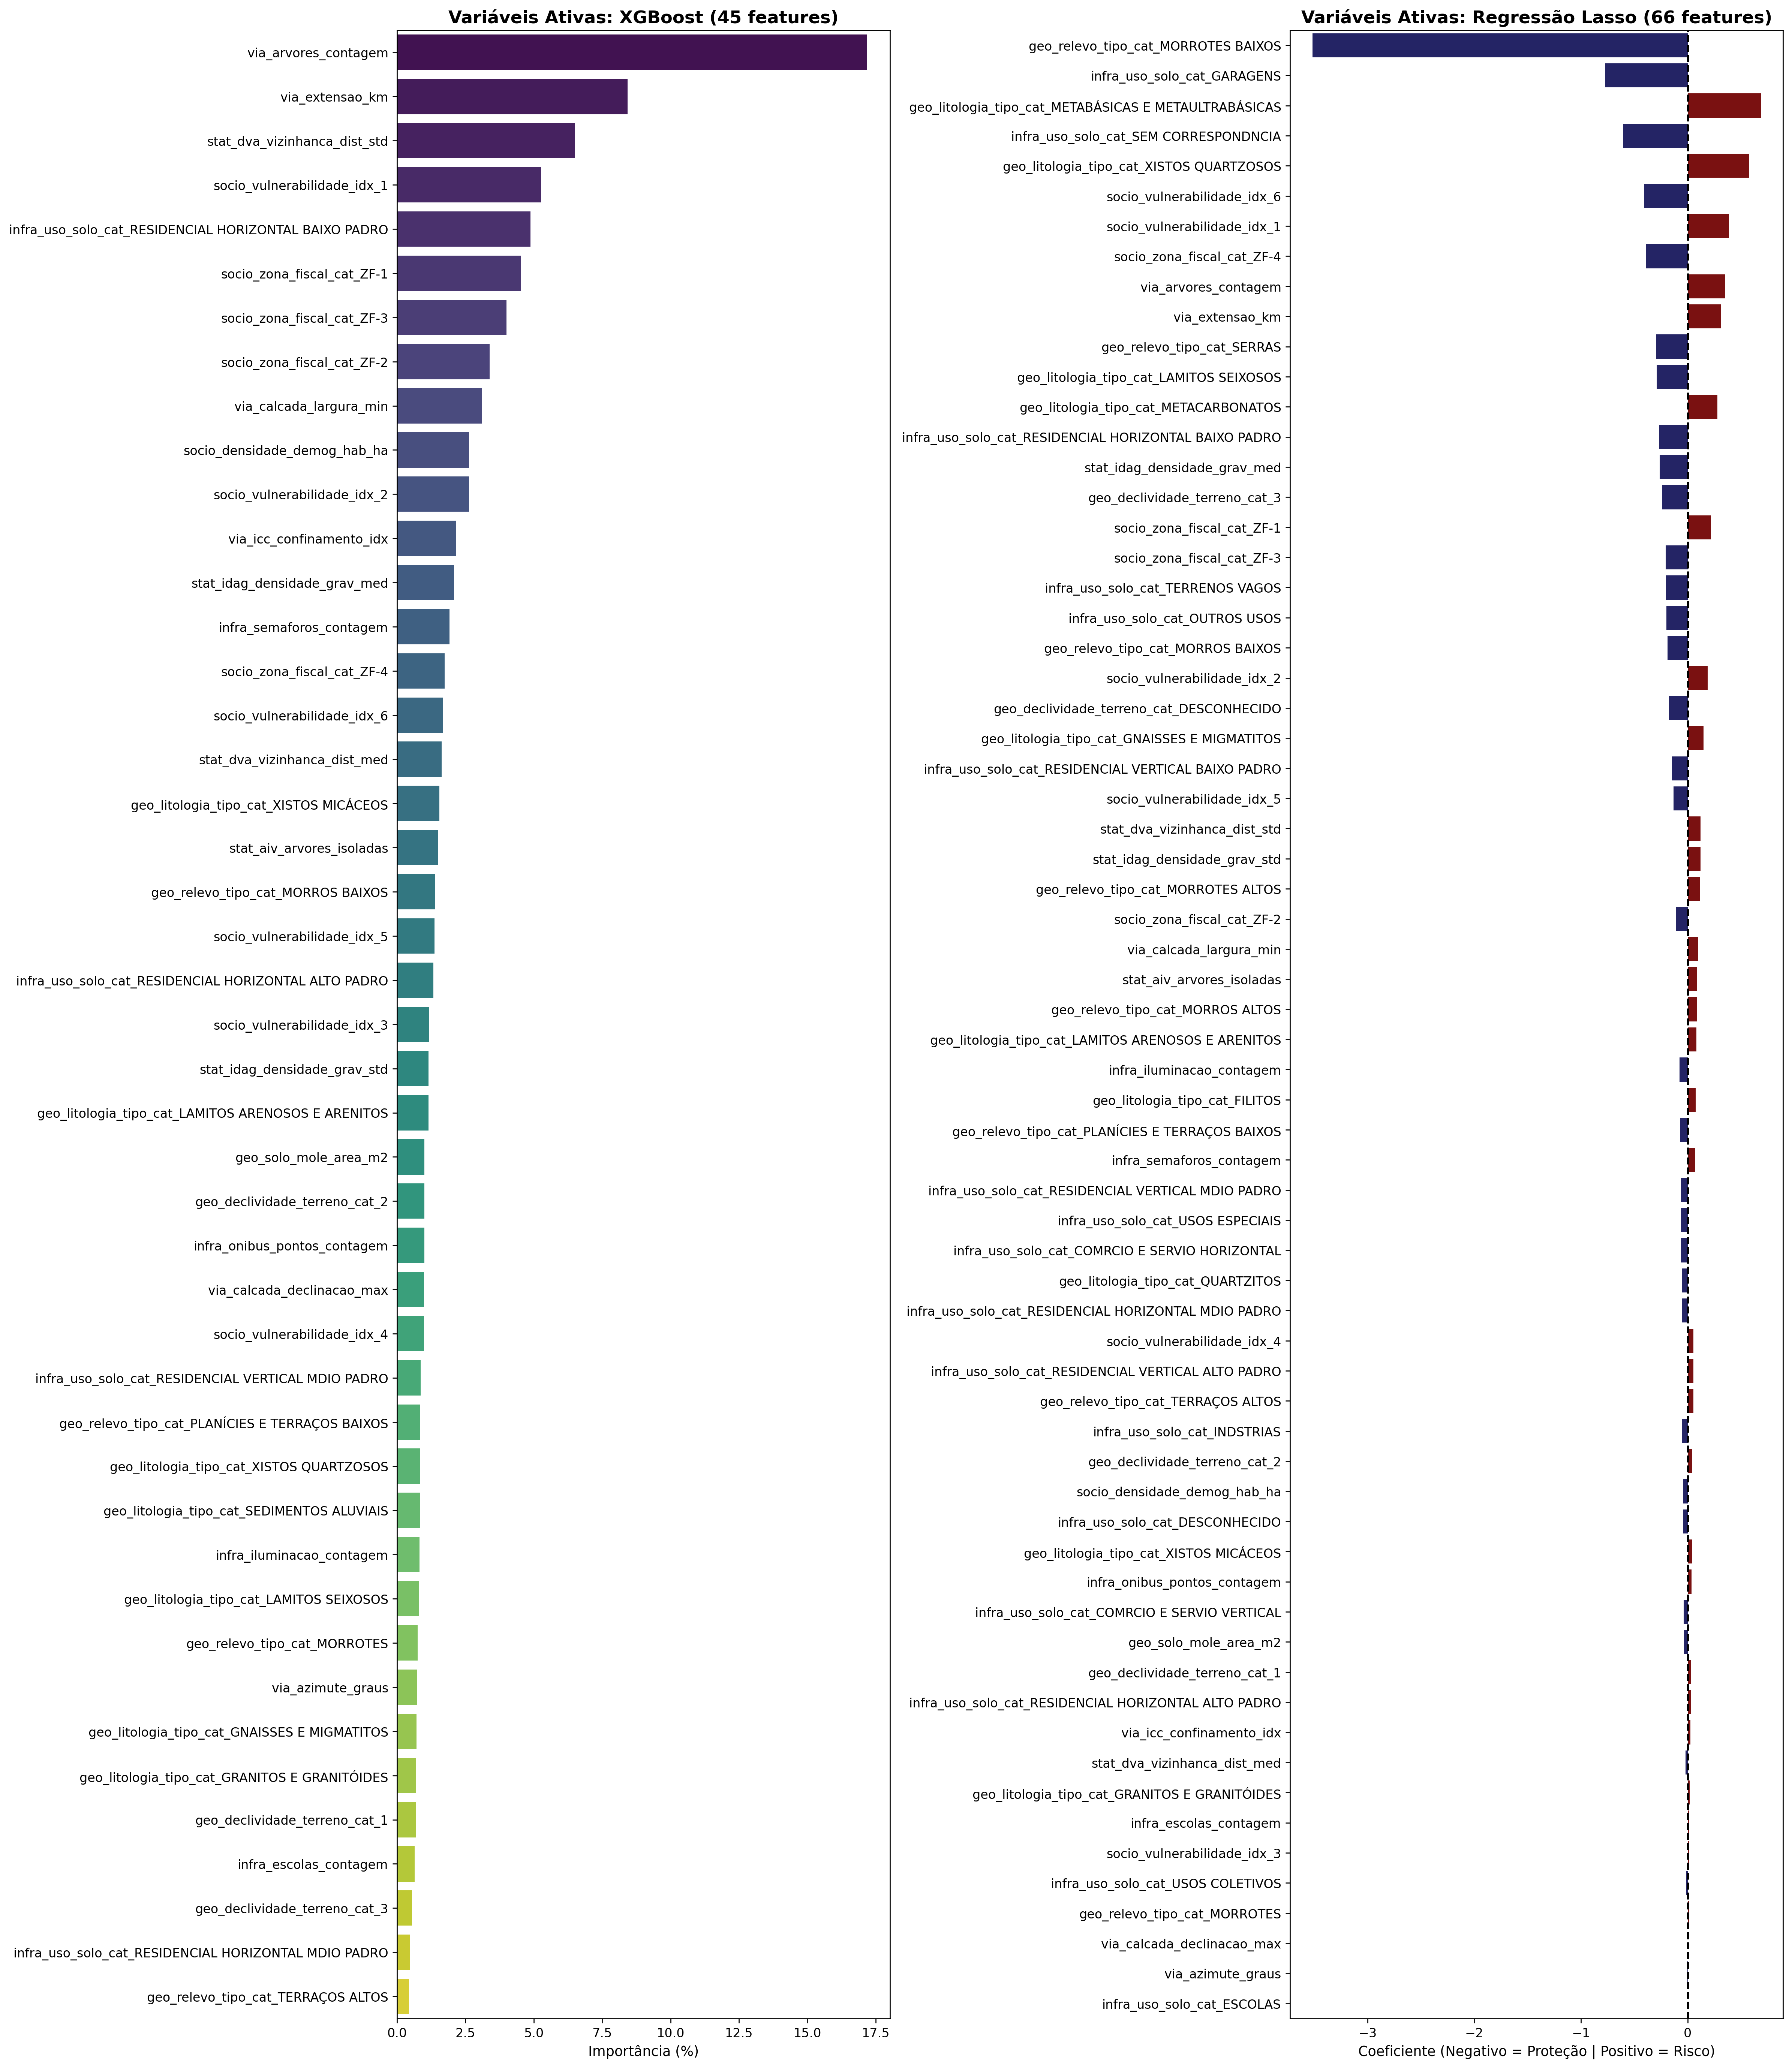

✅ Gráficos exportados com sucesso para: results/figures/05_importancia_exaustiva_modelos__20260402-1338_abrangente.png

🔍 RESUMO DA REGRESSÃO LASSO (Penalidade L1):
 - Sobreviveram: 66 variáveis.
 - Foram ZERADAS (descartadas por redundância ou irrelevância): 2 variáveis.

🗑️ Variáveis descartadas pelo Lasso:
geo_declividade_terreno_cat_4 | geo_litologia_tipo_cat_SEDIMENTOS ALUVIAIS

📈 FATORES DE RISCO (Coeficientes Positivos - Aumentam a chance de queda):
  + geo_litologia_tipo_cat_METABÁSICAS E METAULTRABÁSICAS | Peso: 0.6853
  + geo_litologia_tipo_cat_XISTOS QUARTZOSOS | Peso: 0.5749
  + socio_vulnerabilidade_idx_1    | Peso: 0.3886
  + via_arvores_contagem           | Peso: 0.3520
  + via_extensao_km                | Peso: 0.3126
  + geo_litologia_tipo_cat_METACARBONATOS | Peso: 0.2798
  + socio_zona_fiscal_cat_ZF-1     | Peso: 0.2191
  + socio_vulnerabilidade_idx_2    | Peso: 0.1863
  + geo_litologia_tipo_cat_GNAISSES E MIGMATITOS | Peso: 0.1492
  + stat_dva_vizinhanca_dist_std   

In [21]:
# ==============================================================================
# CÉLULA 10: INTERPRETABILIDADE EXAUSTIVA (LASSO E XGBOOST LADO A LADO)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("📊 Extraindo a importância de todas as variáveis dos modelos...")

# 1. Extração dos Dados Brutos (Usando os nomes atualizados dos pipelines)
coeficientes_lasso = pipe_lasso.named_steps['modelo'].coef_[0]
importancias_xgb = pipe_xgb_final.named_steps['modelo'].feature_importances_ * 100

feature_names = pipe_lasso.named_steps['pre'].get_feature_names_out()
feature_names_clean = [nome.replace('num__', '').replace('cat__', '') for nome in feature_names]

# 2. Consolidando no DataFrame Principal
df_importancia = pd.DataFrame({
    'Feature': feature_names_clean,
    'XGBoost (Força %)': importancias_xgb,
    'Lasso (Coeficiente)': coeficientes_lasso
})

# 3. Filtragem Independente para cada Modelo
# XGBoost: Apenas variáveis que contribuíram com algum ganho de informação (> 0)
df_xgb_plot = df_importancia[df_importancia['XGBoost (Força %)'] > 0].sort_values(by='XGBoost (Força %)', ascending=False)

# Lasso: Apenas variáveis que sobreviveram à penalidade L1 (!= 0)
df_lasso_plot = df_importancia[df_importancia['Lasso (Coeficiente)'] != 0].copy()
df_lasso_plot['Abs_Lasso'] = df_lasso_plot['Lasso (Coeficiente)'].abs()
df_lasso_plot = df_lasso_plot.sort_values(by='Abs_Lasso', ascending=False)

# Lasso: Variáveis Zeradas (Descartadas)
df_lasso_zeradas = df_importancia[df_importancia['Lasso (Coeficiente)'] == 0][['Feature']].copy()

# 4. Salvando as tabelas completas para o relatório (Padrão PT-BR)
caminho_tabela_xgb = f'results/tables/11a_importancia_xgboost_{sufixo_data}.csv'
caminho_tabela_lasso = f'results/tables/11b_importancia_lasso_{sufixo_data}.csv'

df_xgb_plot.to_csv(caminho_tabela_xgb, index=False, sep=';', decimal=',')
df_lasso_plot.drop(columns=['Abs_Lasso']).to_csv(caminho_tabela_lasso, index=False, sep=';', decimal=',')

# ==========================================
# 5. PLOTANDO OS GRÁFICOS DINÂMICOS
# ==========================================
# Calcula a altura ideal do gráfico baseado no modelo que tem mais variáveis ativas
max_vars = max(len(df_xgb_plot), len(df_lasso_plot))
altura_ideal = max(8, max_vars * 0.35)

fig, axes = plt.subplots(1, 2, figsize=(20, altura_ideal), dpi=120)

# Gráfico 1: XGBoost (Força Absoluta)
sns.barplot(x='XGBoost (Força %)', y='Feature', data=df_xgb_plot, ax=axes[0], palette='viridis')
axes[0].set_title(f'Variáveis Ativas: XGBoost ({len(df_xgb_plot)} features)', fontsize=14, weight='bold')
axes[0].set_xlabel('Importância (%)')
axes[0].set_ylabel('')

# Gráfico 2: Lasso (Direcionalidade)
cores_lasso = ['#8B0000' if val > 0 else '#191970' for val in df_lasso_plot['Lasso (Coeficiente)']]
sns.barplot(x='Lasso (Coeficiente)', y='Feature', data=df_lasso_plot, ax=axes[1], palette=cores_lasso)
axes[1].set_title(f'Variáveis Ativas: Regressão Lasso ({len(df_lasso_plot)} features)', fontsize=14, weight='bold')
axes[1].set_xlabel('Coeficiente (Negativo = Proteção | Positivo = Risco)')
axes[1].set_ylabel('')
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--') # Linha central destacada

plt.tight_layout()
caminho_figura = f'results/figures/05_importancia_exaustiva_modelos_{sufixo_data}.png'
plt.savefig(caminho_figura, dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 6. RELATÓRIO DE DESCARTE (LASSO)
# ==========================================
print(f"✅ Gráficos exportados com sucesso para: {caminho_figura}")
print(f"\n🔍 RESUMO DA REGRESSÃO LASSO (Penalidade L1):")
print(f" - Sobreviveram: {len(df_lasso_plot)} variáveis.")
print(f" - Foram ZERADAS (descartadas por redundância ou irrelevância): {len(df_lasso_zeradas)} variáveis.")

if len(df_lasso_zeradas) > 0:
    print("\n🗑️ Variáveis descartadas pelo Lasso:")
    lista_zeradas = df_lasso_zeradas['Feature'].tolist()
    for i in range(0, len(lista_zeradas), 3):
        print(" | ".join(lista_zeradas[i:i+3]))

# ==============================================================================
# 7. RELATÓRIO DETALHADO: FATORES DE RISCO E PROTEÇÃO (LASSO)
# ==============================================================================
print("\n📈 FATORES DE RISCO (Coeficientes Positivos - Aumentam a chance de queda):")
risco_lasso = df_lasso_plot[df_lasso_plot['Lasso (Coeficiente)'] > 0].sort_values(by='Lasso (Coeficiente)', ascending=False)

if not risco_lasso.empty:
    for _, row in risco_lasso.iterrows():
        print(f"  + {row['Feature']:<30} | Peso: {row['Lasso (Coeficiente)']:.4f}")
else:
    print("  Nenhum fator de risco retido pelo modelo.")

print("\n🛡️ FATORES DE PROTEÇÃO (Coeficientes Negativos - Reduzem a chance de queda):")
protecao_lasso = df_lasso_plot[df_lasso_plot['Lasso (Coeficiente)'] < 0].sort_values(by='Lasso (Coeficiente)', ascending=True)

if not protecao_lasso.empty:
    for _, row in protecao_lasso.iterrows():
        print(f"  - {row['Feature']:<30} | Peso: {row['Lasso (Coeficiente)']:.4f}")
else:
    print("  Nenhum fator de proteção retido pelo modelo.")

In [ ]:
# ==============================================================================
# ÚLTIMA CÉLULA (02_modelagem): EXPORTAÇÃO DO MODELO E METADADOS
# ==============================================================================
import joblib
import os

print("💾 Salvando o modelo XGBoost final, Threshold e Metadados do Treino...")

os.makedirs('results/models', exist_ok=True)

# 1. Nomes dos arquivos baseados no cenário
caminho_modelo = f'results/models/modelo_xgb_{nome_cenario}.pkl'
caminho_threshold = f'results/models/threshold_{nome_cenario}.pkl'
caminho_metadados = f'results/models/metadados_{nome_cenario}.pkl'

# 2. Capturando a inteligência do pré-processamento
metadados = {
    'features_numericas': features_numericas,
    'features_categoricas': features_categoricas,
    # Guarda as medianas do treino para preencher NAs nos dados novos da cidade
    'medianas_treino': X_train[features_numericas].median().to_dict()
}

# 3. Exportação física para o disco
joblib.dump(pipe_xgb_final, caminho_modelo)
joblib.dump(threshold_otimo, caminho_threshold)
joblib.dump(metadados, caminho_metadados)

print(f"✅ Modelo salvo: {caminho_modelo}")
print(f"✅ Threshold ({threshold_otimo:.2f}) salvo: {caminho_threshold}")
print(f"✅ Metadados das features salvos: {caminho_metadados}")
print("🚀 O notebook 03_mapa agora pode rodar de forma totalmente independente!")

💾 Salvando o modelo XGBoost final, Threshold e Metadados do Treino...
✅ Modelo salvo: results/models/modelo_xgb_abrangente.pkl
✅ Threshold (0.44) salvo: results/models/threshold_abrangente.pkl
✅ Metadados das features salvos: results/models/metadados_abrangente.pkl
🚀 O notebook 03_mapa agora pode rodar de forma totalmente independente!
